In [1]:


import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from analysis_of_simulation_result import * 

import numpy as np 
import pandas as pd 
import os 
import pickle
from cell_groups import *

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7
fontsize=7

In [4]:
DATA_DIR = Path(REPO_ROOT/'figure5/figure5B,C,H,I_necessity/data')
tarsal_geo_df = pd.read_parquet(DATA_DIR/'tarsal_screening.parquet')
tarsal_geo_df.index.name = 'type'
tarsal_geo_df.columns = pd.MultiIndex.from_product(
    [['sucrose [mM]'], tarsal_geo_df.columns])

tarsal_geo_sem = pd.read_parquet(DATA_DIR/'tarsal_screening_sem.parquet')
tarsal_geo_sem.index.name = 'type'
tarsal_geo_sem.columns = pd.MultiIndex.from_product(
    [['sucrose [mM]'], tarsal_geo_sem.columns])

labial_geo_df = pd.read_parquet(DATA_DIR/'labellar_screening.parquet')
labial_geo_df.index.name = 'type'
labial_geo_df.columns = pd.MultiIndex.from_product(
    [['sucrose [mM]'], labial_geo_df.columns])


labial_geo_sem = pd.read_parquet(DATA_DIR/'labellar_screening_sem.parquet')
labial_geo_sem.index.name = 'type'
labial_geo_sem.columns = pd.MultiIndex.from_product(
    [['sucrose [mM]'], labial_geo_sem.columns])


# with pd.ExcelWriter('Sweet_Screening_simulation.xlsx') as writer:
#     tarsal_geo_df.to_excel(writer, sheet_name='tarsal')
#     labial_geo_df.to_excel(writer, sheet_name='labellar')
    
# with pd.ExcelWriter('Sweet_Screening_simulation_sem.xlsx') as writer:
#     tarsal_geo_sem.to_excel(writer, sheet_name='tarsal')
#     labial_geo_sem.to_excel(writer, sheet_name='labellar')

In [5]:
tarsal_geo_df = pd.read_parquet(DATA_DIR/'tarsal_geosmin_screening.parquet')
tarsal_geo_df.index.name = 'type'
tarsal_geo_df.columns = pd.MultiIndex.from_product(
    [['sucrose [mM]'], tarsal_geo_df.columns])

tarsal_geo_sem = pd.read_parquet(DATA_DIR/'tarsal_geosmin_screening_sem.parquet')
tarsal_geo_sem.index.name = 'type'
tarsal_geo_sem.columns = pd.MultiIndex.from_product(
    [['sucrose [mM]'], tarsal_geo_sem.columns])

labial_geo_df = pd.read_parquet(DATA_DIR/'labial_geosmin_screening.parquet')
labial_geo_df.index.name = 'type'
labial_geo_df.columns = pd.MultiIndex.from_product(
    [['sucrose [mM]'], labial_geo_df.columns])


labial_geo_sem = pd.read_parquet(DATA_DIR/'labial_geosmin_screening_sem.parquet')
labial_geo_sem.index.name = 'type'
labial_geo_sem.columns = pd.MultiIndex.from_product(
    [['sucrose [mM]'], labial_geo_sem.columns])


# with pd.ExcelWriter('Geosmin_Screening_simulation.xlsx') as writer:
#     tarsal_geo_df.to_excel(writer, sheet_name='tarsal')
#     labial_geo_df.to_excel(writer, sheet_name='labellar')
    
# with pd.ExcelWriter('Geosmin_Screening_simulation_sem.xlsx') as writer:
#     tarsal_geo_sem.to_excel(writer, sheet_name='tarsal')
#     labial_geo_sem.to_excel(writer, sheet_name='labellar')

In [6]:
def load_screening_result(filename, sheet_name):
    df = pd.read_excel(
        DATA_DIR / filename,
        sheet_name=sheet_name,
        header=1,
        index_col=0,
    )

    if "type" in df.index:
        df = df.drop(index="type")

    df.index.name = "type"
    return df

### Sweet ###
# Tarsal
tarsal_screening_per = load_screening_result(
    "Sweet_Screening_simulation.xlsx",
    "tarsal",
)
tarsal_screening_per_sem = load_screening_result(
    "Sweet_Screening_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_screening_per = load_screening_result(
    "Sweet_Screening_simulation.xlsx",
    "labellar",
)
labial_screening_per_sem = load_screening_result(
    "Sweet_Screening_simulation_sem.xlsx",
    "labellar",
)


### Geosmin ###
tarsal_geosmin_screening_per = load_screening_result(
    "Geosmin_Screening_simulation.xlsx",
    "tarsal",
)
tarsal_geosmin_screening_per_sem = load_screening_result(
    "Geosmin_Screening_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_geosmin_screening_per = load_screening_result(
    "Geosmin_Screening_simulation.xlsx",
    "labellar",
)
labial_geosmin_screening_per_sem = load_screening_result(
    "Geosmin_Screening_simulation_sem.xlsx",
    "labellar",
)



In [7]:
sez_ids = np.concatenate(list(sez.values()))
fid2sez_g = {c:t for t,cids in sez.items() for c in cids}

gids = np.unique(np.concatenate([tarsal_screening_per.index[1:],labial_screening_per.index[1:],tarsal_geosmin_screening_per.index[1:],labial_geosmin_screening_per.index[1:]]))

canonical_name = []
for g in gids:
    g = int(g)
    fids = target_ids_valid_all[g_info_all==g]
    if np.any(np.isin(fids,sez_ids)):
        canonical_name.append(fid2sez_g[fids[np.isin(fids,sez_ids)][0]])
    else:
        canonical_name.append(str(g))
gid2canonical_name = dict(zip(gids,canonical_name))
gid2canonical_name['control'] = 'control'

# Tarsal

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


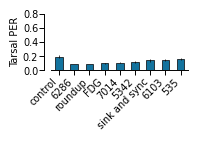

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

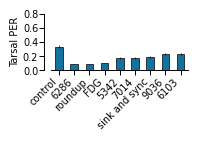

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

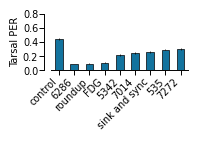

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

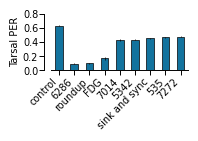

In [39]:

for concentration in [10,50,100,500]:


    df = pd.DataFrame({
        'mean': tarsal_screening_per[concentration],
        'sem': tarsal_screening_per_sem[concentration],
    })

    df = df.sort_values('mean')

    order = ['control', *df.index.drop('control')]
    df = df.loc[order]

    # index 이름 변환
    df.index = [gid2canonical_name[x] for x in df.index]

    colors = cmap = ['#13739E','#952B7E']

    plot_df = pd.concat([
        df.loc[['control']],
        df.drop(index='control').nsmallest(8, 'mean'),
    ])

    cmap = ['#13739E', '#952B7E']
    lp = 2

    bar_spacing = 0.15
    bar_width = 0.075
    num_bars = len(plot_df)
    xloc = np.arange(num_bars) * bar_spacing

    fig, ax = plt.subplots(figsize=(1.8, .9))

    ax.bar(
        xloc,
        plot_df['mean'],
        yerr=plot_df['sem'],
        width=bar_width,
        color=cmap[0],
        edgecolor='black',
        linewidth=0.5,
        error_kw={
            'capsize': 0,
            'elinewidth': 0.5,
        },
    )

    xlabel = [
        'control' if name == 'control' else name
        for name in plot_df.index
    ]

    ax.set_xticks(
        xloc,
        xlabel,
        fontsize=fontsize,
        rotation=45,
        ha='right',
    )

    yticks = np.arange(0, 1, 0.2)
    ax.set_yticks(
        yticks,
        np.round(yticks, 2),
        fontsize=fontsize,
    )

    ax.set_ylabel(
        'Tarsal PER',
        fontsize=fontsize,
        labelpad=lp,
    )

    ax.set_ylim(0, 0.8)
    ax.set_xlim(
        -bar_spacing / 2,
        xloc[-1] + bar_spacing / 2,
    )

    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.tick_params(pad=1)

    LEFT = 0.22
    RIGHT = 0.98
    TOP = 0.95
    BOTTOM = 0.32      # 45도 xtick 기준으로 통일
    fig.subplots_adjust(
        left=LEFT,
        right=RIGHT,
        top=TOP,
        bottom=BOTTOM
    )
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)

    # tick 굵기
    ax.tick_params(
        axis='both',
        width=0.7,
        pad=1
    )
    plt.savefig(f'figures/Necessity/Simulated_screening_Tarsal_barplot_{concentration}.svg')

# Labellar 

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


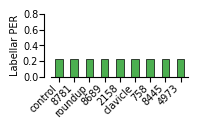

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

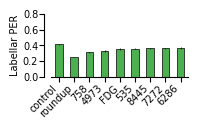

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

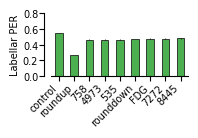

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

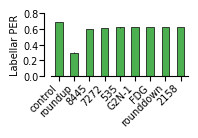

In [20]:
for concentration in [10,50,100,500]:

    df = pd.DataFrame({
        'mean': labial_screening_per[concentration],
        'sem': labial_screening_per_sem[concentration],
    })

    df = df.sort_values('mean')

    order = ['control', *df.index.drop('control')]
    df = df.loc[order]

    # index 이름 변환
    df.index = [gid2canonical_name[x] for x in df.index]


    colors = cmap = ['#4CAF50']

    plot_df = pd.concat([
        df.loc[['control']],
        df.drop(index='control').nsmallest(8, 'mean'),
    ])

    lp = 2

    bar_spacing = 0.15
    bar_width = 0.075
    num_bars = len(plot_df)
    xloc = np.arange(num_bars) * bar_spacing

    fig, ax = plt.subplots(figsize=(1.8, 1))

    ax.bar(
        xloc,
        plot_df['mean'],
        yerr=plot_df['sem'],
        width=bar_width,
        color=cmap[0],
        edgecolor='black',
        linewidth=0.5,
        error_kw={
            'capsize': 0,
            'elinewidth': 0.5,
        },
    )

    xlabel = [
        'control' if name == 'control' else name
        for name in plot_df.index
    ]

    ax.set_xticks(
        xloc,
        xlabel,
        fontsize=fontsize,
        rotation=45,
        ha='right',
    )

    yticks = np.arange(0, 1, 0.2)
    ax.set_yticks(
        yticks,
        np.round(yticks, 2),
        fontsize=fontsize,
    )

    ax.set_ylabel(
        'Labellar PER',
        fontsize=fontsize,
        labelpad=lp,
    )

    ax.set_ylim(0, 0.8)
    ax.set_xlim(
        -bar_spacing / 2,
        xloc[-1] + bar_spacing / 2,
    )

    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.tick_params(pad=1)


    LEFT = 0.22
    RIGHT = 0.98
    TOP = 0.95
    BOTTOM = 0.32      # 45도 xtick 기준으로 통일
    fig.subplots_adjust(
        left=LEFT,
        right=RIGHT,
        top=TOP,
        bottom=BOTTOM
    )
    plt.savefig(f'figures/Necessity/Simulated_screening_Labellar_barplot_{concentration}.svg')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

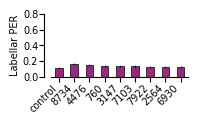

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

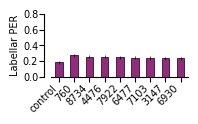

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

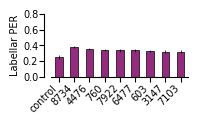

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

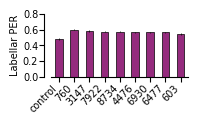

In [32]:
for concentration in [10,50,100,500]:

    df = pd.DataFrame({
        'mean': tarsal_geosmin_screening_per[concentration],
        'sem': tarsal_geosmin_screening_per_sem[concentration],
    })

    df = df.sort_values('mean',ascending=False)

    order = ['control', *df.index.drop('control')]
    df = df.loc[order]

    # index 이름 변환
    df.index = [gid2canonical_name[x] for x in df.index]


    colors = cmap = ['#952B7E']

    plot_df = pd.concat([
        df.loc[['control']],
        df.drop(index='control').nlargest(8, 'mean'),
    ])

    lp = 2

    bar_spacing = 0.15
    bar_width = 0.075
    num_bars = len(plot_df)
    xloc = np.arange(num_bars) * bar_spacing

    fig, ax = plt.subplots(figsize=(1.8, 1))

    ax.bar(
        xloc,
        plot_df['mean'],
        yerr=plot_df['sem'],
        width=bar_width,
        color=cmap[0],
        edgecolor='black',
        linewidth=0.5,
        error_kw={
            'capsize': 0,
            'elinewidth': 0.5,
        },
    )

    xlabel = [
        'control' if name == 'control' else name
        for name in plot_df.index
    ]

    ax.set_xticks(
        xloc,
        xlabel,
        fontsize=fontsize,
        rotation=45,
        ha='right',
    )

    yticks = np.arange(0, 1, 0.2)
    ax.set_yticks(
        yticks,
        np.round(yticks, 2),
        fontsize=fontsize,
    )

    ax.set_ylabel(
        'Labellar PER',
        fontsize=fontsize,
        labelpad=lp,
    )

    ax.set_ylim(0, 0.8)
    ax.set_xlim(
        -bar_spacing / 2,
        xloc[-1] + bar_spacing / 2,
    )

    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.tick_params(pad=1)


    LEFT = 0.22
    RIGHT = 0.98
    TOP = 0.95
    BOTTOM = 0.32      # 45도 xtick 기준으로 통일
    fig.subplots_adjust(
        left=LEFT,
        right=RIGHT,
        top=TOP,
        bottom=BOTTOM
    )
#     plt.savefig(f'figures/Necessity/Simulated_screening_Labellar_barplot_{concentration}.svg')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

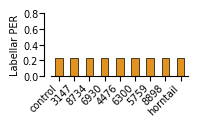

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

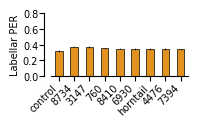

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

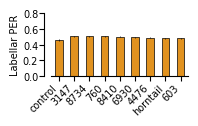

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

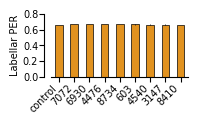

In [33]:
for concentration in [10,50,100,500]:

    df = pd.DataFrame({
        'mean': labial_geosmin_screening_per[concentration],
        'sem': labial_geosmin_screening_per_sem[concentration],
    })

    df = df.sort_values('mean',ascending=False)

    order = ['control', *df.index.drop('control')]
    df = df.loc[order]

    # index 이름 변환
    df.index = [gid2canonical_name[x] for x in df.index]


    colors = cmap = ['#E1921F']

    plot_df = pd.concat([
        df.loc[['control']],
        df.drop(index='control').nlargest(8, 'mean'),
    ])

    lp = 2

    bar_spacing = 0.15
    bar_width = 0.075
    num_bars = len(plot_df)
    xloc = np.arange(num_bars) * bar_spacing

    fig, ax = plt.subplots(figsize=(1.8, 1))

    ax.bar(
        xloc,
        plot_df['mean'],
        yerr=plot_df['sem'],
        width=bar_width,
        color=cmap[0],
        edgecolor='black',
        linewidth=0.5,
        error_kw={
            'capsize': 0,
            'elinewidth': 0.5,
        },
    )

    xlabel = [
        'control' if name == 'control' else name
        for name in plot_df.index
    ]

    ax.set_xticks(
        xloc,
        xlabel,
        fontsize=fontsize,
        rotation=45,
        ha='right',
    )

    yticks = np.arange(0, 1, 0.2)
    ax.set_yticks(
        yticks,
        np.round(yticks, 2),
        fontsize=fontsize,
    )

    ax.set_ylabel(
        'Labellar PER',
        fontsize=fontsize,
        labelpad=lp,
    )

    ax.set_ylim(0, 0.8)
    ax.set_xlim(
        -bar_spacing / 2,
        xloc[-1] + bar_spacing / 2,
    )

    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.tick_params(pad=1)


    LEFT = 0.22
    RIGHT = 0.98
    TOP = 0.95
    BOTTOM = 0.32      # 45도 xtick 기준으로 통일
    fig.subplots_adjust(
        left=LEFT,
        right=RIGHT,
        top=TOP,
        bottom=BOTTOM
    )
#     plt.savefig(f'figures/Necessity/Simulated_screening_Labellar_barplot_{concentration}.svg')